# ML1 - GridSearch avec RandomForestRegressor

Ce notebook fait suite au notebook ML1_Pipeline_Model et se concentre sur :
1. L'utilisation de RandomForestRegressor
2. L'optimisation des hyperparamètres avec GridSearchCV
3. La validation croisée (cross-validation)

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration de l'affichage
#plt.style.use('seaborn')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

## 2. Chargement et préparation des données

Nous reprenons les mêmes étapes de préparation que dans le notebook précédent.

In [2]:
# Chargement des données
df = pd.read_pickle('./data/data.pkl')

# Suppression des NaN dans la target et séparation features/target
target = 'anneedeplantation'
df = df.dropna(subset=[target], axis=0)

X = df.drop(columns=[target])  # Features
y = df[target]                 # Target

# Identification des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 3. Création du pipeline complet avec RandomForestRegressor

Nous allons créer un pipeline qui inclut :
1. Le prétraitement des données (comme avant)
2. Le modèle RandomForestRegressor

In [3]:
# Création du pipeline complet
full_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), categorical_features)
        ]
    )),
    ('model', RandomForestRegressor(random_state=42))
])

In [4]:
full_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4. Cross-validation initiale

Avant d'optimiser les hyperparamètres, évaluons notre modèle avec les paramètres par défaut en utilisant la validation croisée.

In [5]:
# Validation croisée avec 5 folds
cv_scores = cross_val_score(full_pipeline, X_train, y_train, 
                           cv=5, scoring='neg_mean_squared_error')

# Conversion des MSE en RMSE
rmse_scores = np.sqrt(-cv_scores)

print("Scores RMSE par fold :")
for fold, score in enumerate(rmse_scores, 1):
    print(f"Fold {fold}: {score:.2f} ans")
print(f"\nRMSE moyen: {rmse_scores.mean():.2f} ans (±{rmse_scores.std()*2:.2f})")

Scores RMSE par fold :
Fold 1: 7.88 ans
Fold 2: 7.97 ans
Fold 3: 7.50 ans
Fold 4: 7.55 ans
Fold 5: 7.58 ans

RMSE moyen: 7.70 ans (±0.38)


## 5. GridSearch pour l'optimisation des hyperparamètres

Nous allons tester différentes combinaisons d'hyperparamètres pour trouver la meilleure configuration :
- n_estimators : nombre d'arbres dans la forêt
- max_depth : profondeur maximale des arbres
- min_samples_split : nombre minimum d'échantillons requis pour diviser un nœud
- min_samples_leaf : nombre minimum d'échantillons requis dans une feuille

In [6]:
# Définition de la grille de paramètres
param_grid = {
    'model__n_estimators': [10, 50, 100],
    'model__max_depth': [5, 10, 15]
}

# Création du GridSearchCV
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Utilise tous les cœurs disponibles
    verbose=1,
    return_train_score=True
)

# Entraînement avec GridSearch
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__n_estimators': [10, 50, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


## 6. Analyse des résultats du GridSearch

In [7]:
# Affichage des meilleurs paramètres
print("Meilleurs paramètres trouvés :")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

# Conversion du meilleur score en RMSE
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"\nMeilleur RMSE (cross-validation): {best_rmse:.2f} ans")

# Création d'un DataFrame avec tous les résultats
results = pd.DataFrame(grid_search.cv_results_)
results['rmse'] = np.sqrt(-results['mean_test_score'])

# Affichage des 5 meilleures combinaisons
print("\nTop 5 des meilleures combinaisons :")
top_5 = results.nsmallest(5, 'rmse')[['params', 'rmse', 'std_test_score']]
display(top_5)

Meilleurs paramètres trouvés :
model__max_depth: 15
model__n_estimators: 100

Meilleur RMSE (cross-validation): 10.01 ans

Top 5 des meilleures combinaisons :


,params,rmse,std_test_score
8,"{'model__max_depth': 15, 'model__n_estimators'...",10.006142,1.836114
7,"{'model__max_depth': 15, 'model__n_estimators'...",10.010950,1.896371
6,"{'model__max_depth': 15, 'model__n_estimators'...",10.183357,2.251706
5,"{'model__max_depth': 10, 'model__n_estimators'...",11.548628,1.732168
4,"{'model__max_depth': 10, 'model__n_estimators'...",11.551267,1.821179


In [8]:
df = pd.DataFrame(grid_search.cv_results_)[['mean_test_score', 'mean_train_score', 'std_test_score']]
df['truc'] = (df.mean_test_score-df.mean_train_score)/df.mean_test_score*100
df

,mean_test_score,mean_train_score,std_test_score,truc
0,-196.955072,-193.316504,3.268829,1.847410
1,-195.645359,-192.088227,3.274482,1.818153
2,-195.504934,-191.933986,3.237323,1.826526
3,-136.323909,-122.195683,2.261827,10.363719
4,-133.431768,-118.751994,1.821179,11.001709
5,-133.370799,-118.341216,1.732168,11.269021
6,-103.700763,-75.291824,2.251706,27.395111
7,-100.219126,-71.809872,1.896371,28.347138
8,-100.122880,-71.617063,1.836114,28.470832


## 7. Évaluation finale sur le set de test

In [9]:
# Prédictions sur le set de test
y_pred = grid_search.predict(X_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Résultats sur le set de test :")
print(f"MAE : {mae:.2f} ans")
print(f"RMSE: {rmse:.2f} ans")
print(f"R² : {r2:.3f}")

Résultats sur le set de test :
MAE : 6.49 ans
RMSE: 9.81 ans
R² : 0.702


In [20]:
#Export du meilleur modèle :
import pickle
with  open("data/ml1_rf_model.pkl", "wb") as f:
    pickle.dump(grid_search.best_estimator_, f)

## 8. Visualisation des prédictions

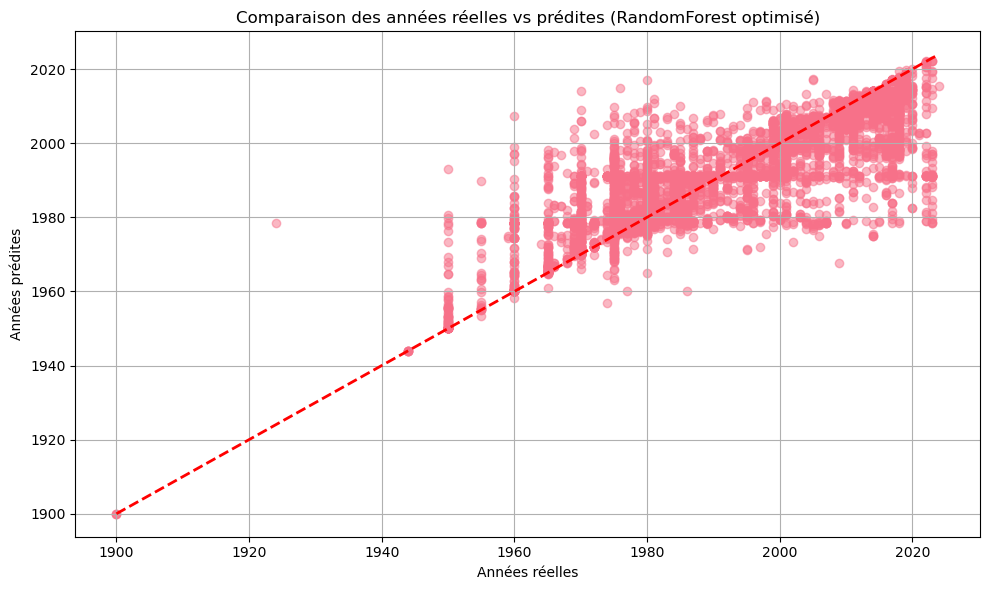

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Années réelles')
plt.ylabel('Années prédites')
plt.title('Comparaison des années réelles vs prédites (RandomForest optimisé)')

plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Importance des features

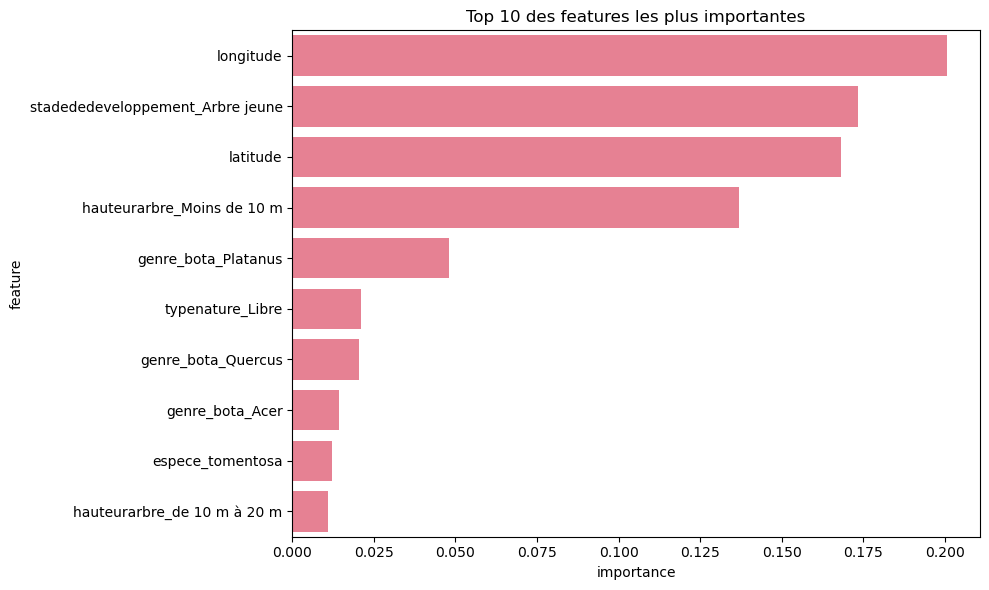

In [11]:
# Récupération des noms de features après transformation
preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
feature_names = (
    numeric_features.tolist() +
    preprocessor.named_transformers_['cat']
    .named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
) 

# Récupération des importances
importances = grid_search.best_estimator_.named_steps['model'].feature_importances_

# Création d'un DataFrame pour l'affichage
feature_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_imp = feature_imp.sort_values('importance', ascending=False).head(10)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp, x='importance', y='feature')
plt.title('Top 10 des features les plus importantes')
plt.tight_layout()
plt.show()

# 10. Feature selection

In [12]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel

lasso = LassoCV(cv=5)

selector = SelectFromModel(lasso)

pipeline_with_selection = Pipeline([
    ('preprocessor', grid_search.best_estimator_.named_steps['preprocessor']),
    ('selector', selector),
    ('model', RandomForestRegressor())
])

pipeline_with_selection.set_params(**grid_search.best_params_)

pipeline_with_selection.fit(X_train, y_train)

n_selected = pipeline_with_selection.named_steps['selector'].get_support().sum()
total_features = pipeline_with_selection.named_steps['selector'].get_support().shape[0]
print(n_selected, "selected features out of", total_features)


/home/keubou/mambaforge/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.120e+02, tolerance: 7.840e+02
  model = cd_fast.sparse_enet_coordinate_descent(


181 selected features out of 403


In [13]:
# Prédictions sur le set de test

y_pred = pipeline_with_selection.predict(X_test)
# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Résultats sur le set de test :")
print(f"MAE : {mae:.2f} ans")
print(f"RMSE: {rmse:.2f} ans")
print(f"R² : {r2:.3f}")

Résultats sur le set de test :
MAE : 6.43 ans
RMSE: 9.78 ans
R² : 0.705


## Conclusion

Dans ce notebook, nous avons :
1. Mis en place un pipeline complet avec RandomForestRegressor
2. Utilisé la validation croisée pour évaluer le modèle
3. Optimisé les hyperparamètres avec GridSearchCV
4. Analysé l'importance des features

Points importants à retenir :
- La validation croisée permet d'obtenir une estimation plus robuste des performances
- GridSearch permet de trouver automatiquement les meilleurs hyperparamètres
- RandomForest permet d'analyser l'importance des features